In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
df = pd.read_csv("Crop_and_fertilizer_with_usage.csv")
df.head()

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link,Fertilizer_Usage
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,68.86
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,88.52
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,84.69
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,83.16
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo,71.15


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   District_Name     4513 non-null   object 
 1   Soil_color        4513 non-null   object 
 2   Nitrogen          4513 non-null   int64  
 3   Phosphorus        4513 non-null   int64  
 4   Potassium         4513 non-null   int64  
 5   pH                4513 non-null   float64
 6   Rainfall          4513 non-null   int64  
 7   Temperature       4513 non-null   int64  
 8   Crop              4513 non-null   object 
 9   Fertilizer        4513 non-null   object 
 10  Link              4513 non-null   object 
 11  Fertilizer_Usage  4513 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 423.2+ KB


In [142]:
df.describe()

,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Fertilizer_Usage
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,95.409927,54.341901,63.595170,6.715267,819.189010,25.915134,76.587407
std,38.060648,16.551991,35.691911,0.625198,251.730813,5.897328,29.228860
min,20.000000,10.000000,5.000000,5.500000,300.000000,10.000000,13.440000
25%,60.000000,40.000000,40.000000,6.000000,600.000000,20.000000,53.780000
50%,105.000000,55.000000,55.000000,6.500000,800.000000,25.000000,78.470000
75%,125.000000,65.000000,75.000000,7.000000,1000.000000,30.000000,98.020000
max,150.000000,90.000000,150.000000,8.500000,1700.000000,40.000000,150.970000


In [143]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
District_Name       0
Soil_color          0
Nitrogen            0
Phosphorus          0
Potassium           0
pH                  0
Rainfall            0
Temperature         0
Crop                0
Fertilizer          0
Link                0
Fertilizer_Usage    0
dtype: int64


In [144]:
print("Unique Soil Colors:")
print(df["Soil_color"].unique())

print("\nUnique Crops:")
print(df["Crop"].unique())

print("\nNumber of Crops:",
      df["Crop"].nunique())

Unique Soil Colors:
['Black' 'Red ' 'Medium Brown' 'Dark Brown' 'Red' 'Light Brown'
 'Reddish Brown']

Unique Crops:
['Sugarcane' 'Jowar' 'Cotton' 'Rice' 'Wheat' 'Groundnut' 'Maize' 'Tur'
 'Urad' 'Moong' 'Gram' 'Masoor' 'Soybean' 'Ginger' 'Turmeric' 'Grapes']

Number of Crops: 16


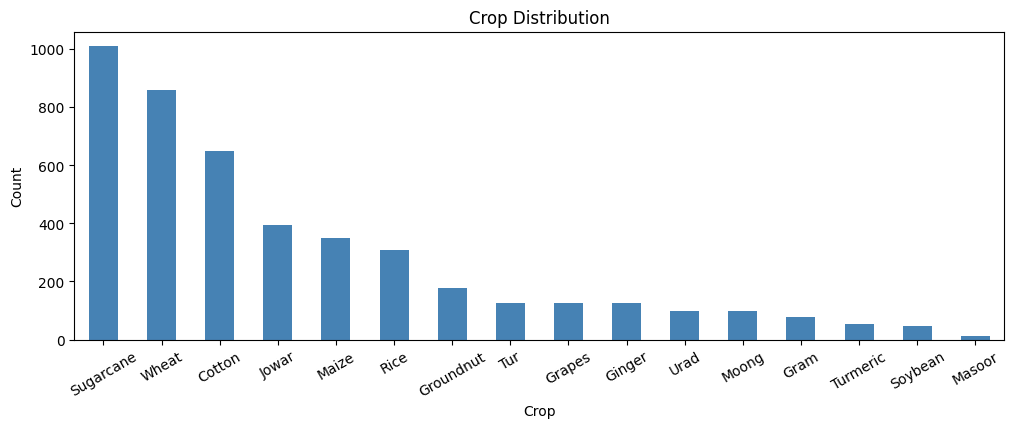

In [145]:
plt.figure(figsize=(12,4))
df['Crop'].value_counts().plot(
    kind='bar',
    color='steelblue')
plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

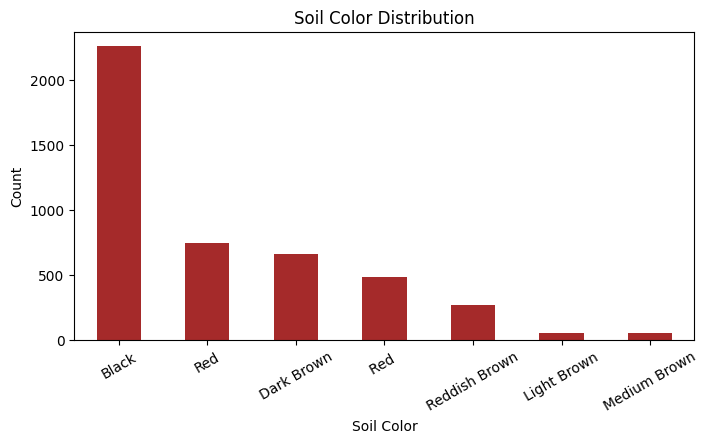

In [146]:
plt.figure(figsize=(8,4))
df['Soil_color'].value_counts().plot(
    kind='bar',
    color='brown')
plt.title('Soil Color Distribution')
plt.xlabel('Soil Color')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

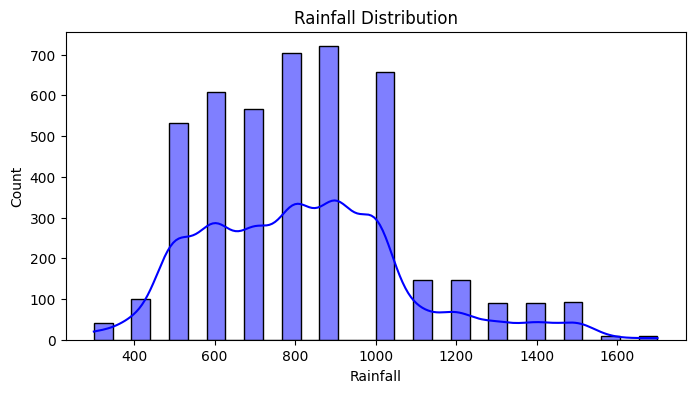

In [147]:
plt.figure(figsize=(8,4))
sns.histplot(df['Rainfall'],
             bins=30,
             kde=True,
             color='blue')
plt.title('Rainfall Distribution')
plt.xlabel('Rainfall')
plt.ylabel('Count')
plt.show()

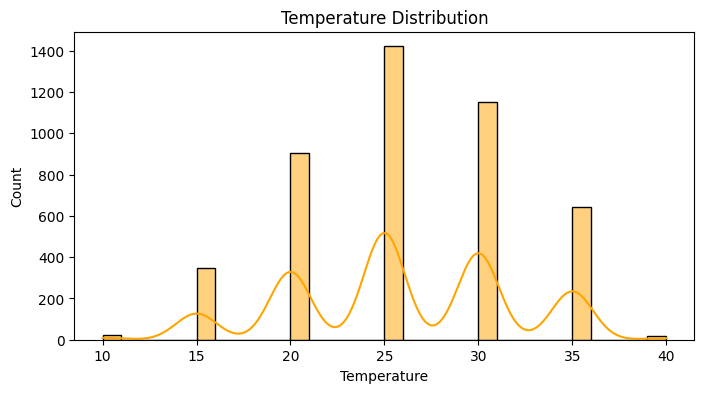

In [148]:
plt.figure(figsize=(8,4))
sns.histplot(df['Temperature'],
             bins=30,
             kde=True,
             color='orange')
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()

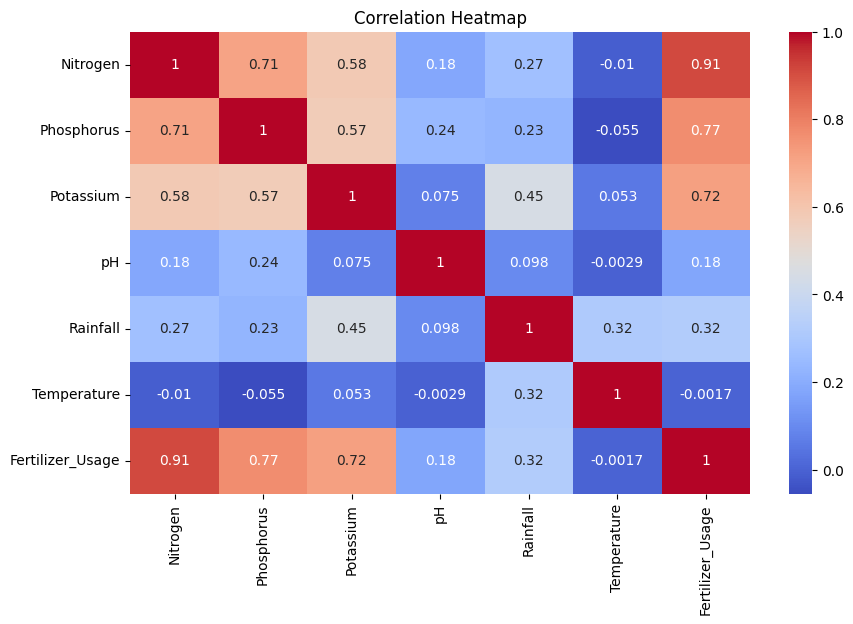

In [149]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [150]:
df.drop(columns=["Fertilizer",
                  "Link",
                  "Fertilizer_Usage"],
        inplace=True)

df.head()

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane


In [151]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['District_Name'] = le.fit_transform(
                      df['District_Name'])
df['Soil_color']    = le.fit_transform(
                      df['Soil_color'])
df['Crop']          = le.fit_transform(
                      df['Crop'])

df.head()

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop
0,0,0,75,50,100,6.5,1000,20,11
1,0,0,80,50,100,6.5,1000,20,11
2,0,0,85,50,100,6.5,1000,20,11
3,0,0,90,50,100,6.5,1000,20,11
4,0,0,95,50,100,6.5,1000,20,11


In [152]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["Crop"])
y = df["Crop"]

print("Features shape:", x.shape)
print("Target shape  :", y.shape)

Features shape: (4513, 8)
Target shape  : (4513,)


In [153]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42)

print("Train size:", xtrain.shape)
print("Test size :", xtest.shape)

Train size: (3610, 8)
Test size : (903, 8)


In [154]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest  = scaler.transform(xtest)

In [155]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(xtrain, ytrain)
lr_pred = lr.predict(xtest)
lr_acc  = accuracy_score(ytest, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8560354374307863


In [156]:
# Train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)
rf.fit(xtrain, ytrain)
rf_pred = rf.predict(xtest)
rf_acc  = accuracy_score(ytest, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9988925802879292


In [157]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(xtrain, ytrain)
rf_pred = rf.predict(xtest)
rf_acc  = accuracy_score(ytest, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9988925802879292


Model Comparison:
Logistic Regression: 0.8560354374307863
Random Forest      : 0.9988925802879292


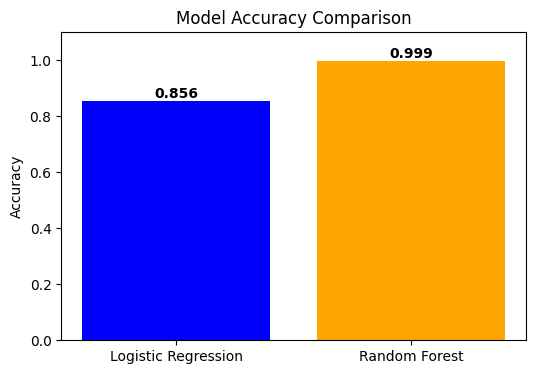

In [158]:
print("Model Comparison:")
print("=" * 40)
print("Logistic Regression:", lr_acc)
print("Random Forest      :", rf_acc)

# Bar chart
plt.figure(figsize=(6,4))
plt.bar(['Logistic Regression',
         'Random Forest'],
        [lr_acc, rf_acc],
        color=['blue','orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
for i, v in enumerate([lr_acc, rf_acc]):
    plt.text(i, v + 0.01,
             str(round(v, 3)),
             ha='center',
             fontweight='bold')
plt.show()

In [159]:
from sklearn.metrics import classification_report

print("Classification Report:")
print("=" * 50)
print(classification_report(ytest, rf_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       146
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00        41
           5       1.00      1.00      1.00        66
           6       1.00      0.99      0.99        72
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00        13
           9       1.00      1.00      1.00        64
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00       205
          12       1.00      1.00      1.00        21
          13       1.00      1.00      1.00        12
          14       1.00      1.00      1.00        18
          15       0.99      1.00      1.00       176

    accuracy                           1.00       903
   

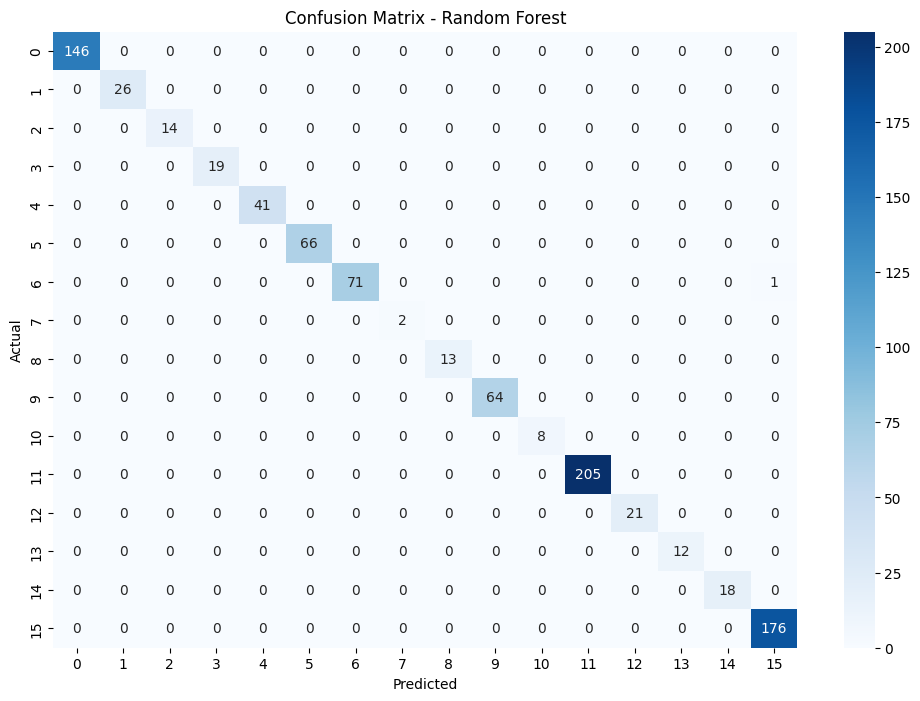

In [160]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ytest, rf_pred)

plt.figure(figsize=(12,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()